First, train a CNN MNIST model and create adversarial images to classify 4s as 9s

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training.images shape:  (60000, 784)
Training.labels shape:  (60000, 10)
Shape of an image:  (784,)
Example label:  [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


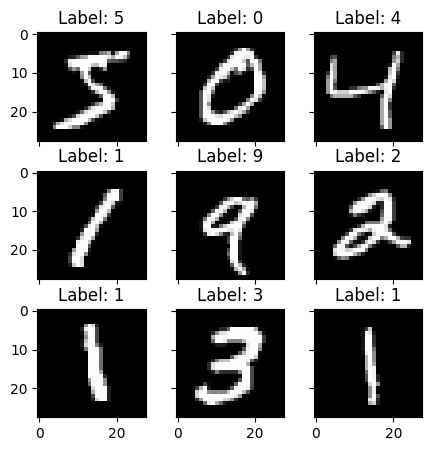

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 179s 326ms/step - accuracy: 0.7799 - loss: 0.8233 - val_accuracy: 0.9740 - val_loss: 0.1029
Epoch 2/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 173s 320ms/step - accuracy: 0.9643 - loss: 0.1232 - val_accuracy: 0.9818 - val_loss: 0.0664
Epoch 3/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 172s 318ms/step - accuracy: 0.9754 - loss: 0.0802 - val_accuracy: 0.9857 - val_loss: 0.0522
Epoch 4/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 208s 329ms/step - accuracy: 0.9815 - loss: 0.0581 - val_accuracy: 0.9888 - val_loss: 0.0466
Epoch 5/5
540/540 ━━━━━━━━━━━━━━━━━━━━ 200s 326ms/step - accuracy: 0.9854 - loss: 0.0454 - val_accuracy: 0.9895 - val_loss: 0.0407
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9951 - loss: 0.0152
Test accuracy: 99.00%


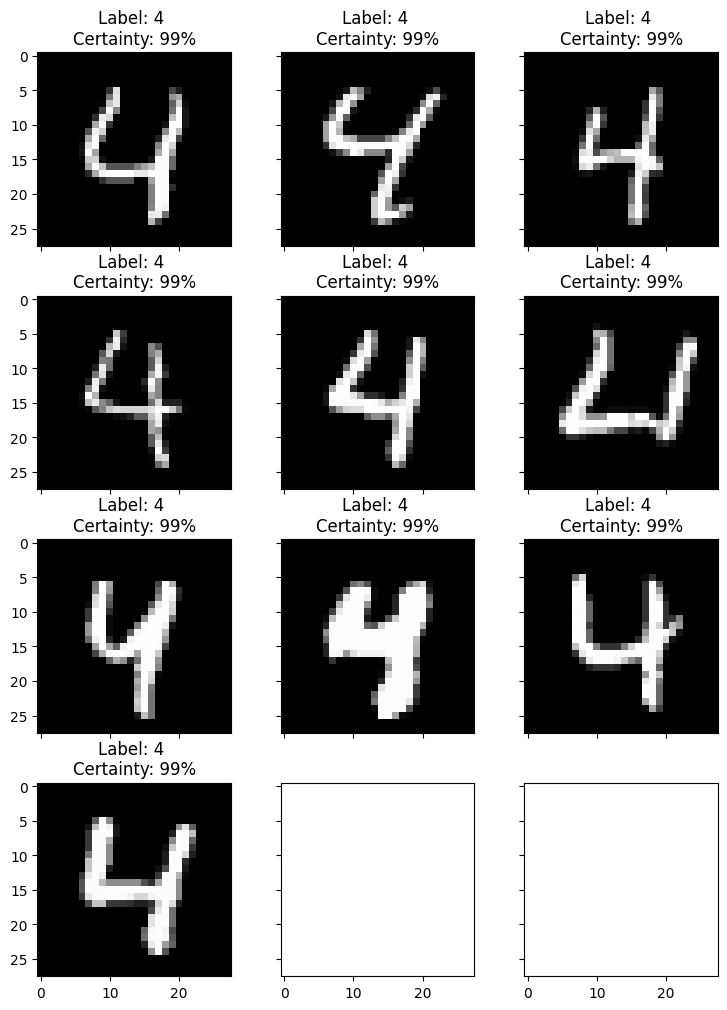

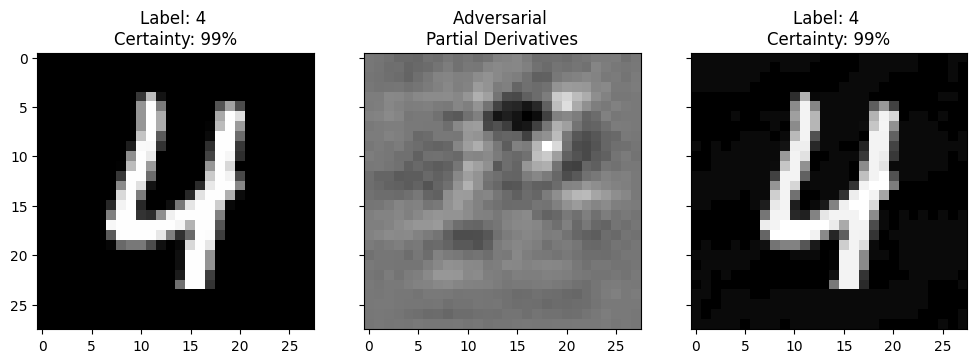

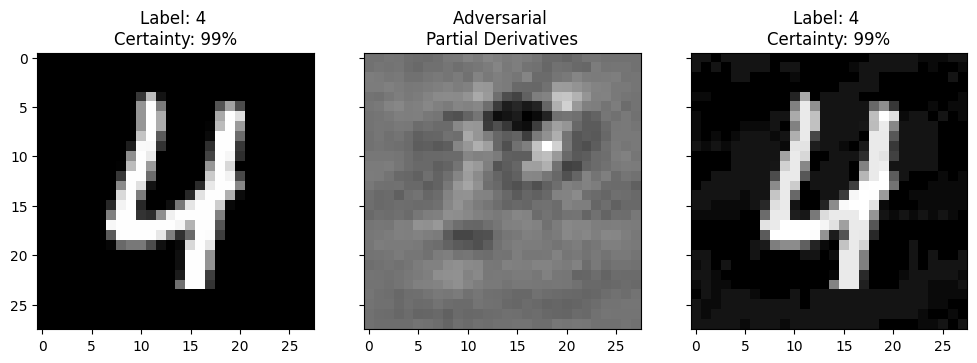

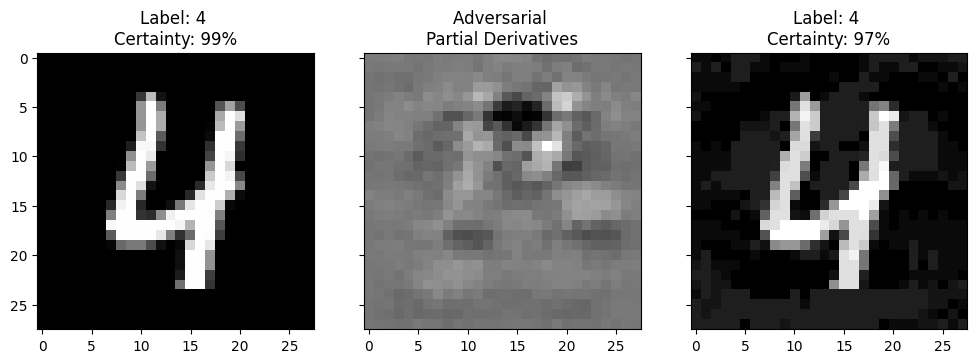

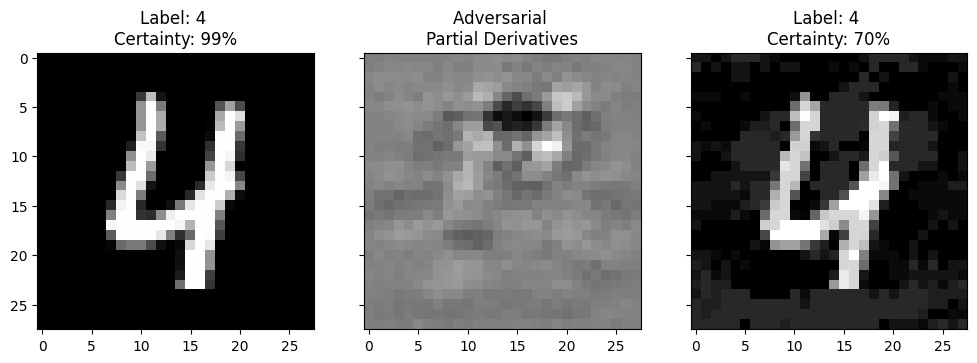

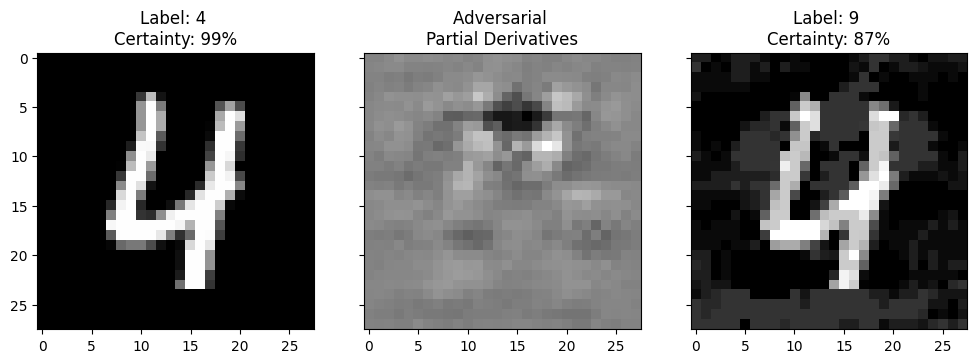

[]

In [2]:
# Dependencies
%matplotlib inline
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28*28).astype('float32') / 255.0
x_test = x_test.reshape(-1, 28*28).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print('Training.images shape: ', x_train.shape)
print('Training.labels shape: ', y_train.shape)
print('Shape of an image: ', x_train[0].shape)
print('Example label: ', y_train[0])

# Plot images
image_list = x_train[0:9]
image_list_labels = y_train[0:9]

fig = plt.figure(1, (5., 5.))
grid = ImageGrid(fig, 111, nrows_ncols=(3, 3), axes_pad=0.3)
for i in range(len(image_list)):
    image = image_list[i].reshape(28,28)
    grid[i].imshow(image, cmap='gray')
    grid[i].set_title('Label: {0}'.format(image_list_labels[i].argmax()))
plt.show()

# Build CNN model using Keras API
model = tf.keras.Sequential([
    tf.keras.layers.Reshape((28,28,1), input_shape=(784,)),
    tf.keras.layers.Conv2D(32, (5,5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Conv2D(64, (5,5), activation='relu', padding='same'),
    tf.keras.layers.MaxPooling2D((2,2), padding='same'),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1024, activation='relu'),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10)
])

loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True)
model.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
              loss=loss_fn,
              metrics=['accuracy'])

# Train
model.fit(x_train, y_train, batch_size=100, epochs=5, validation_split=0.1)

# Evaluate
test_acc = model.evaluate(x_test[:500], y_test[:500])[1]
print("Test accuracy: {:.2f}%".format(test_acc * 100))

# Softmax output layer (needed for adversarial visualization)
prob_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])

# Plot predictions
def plot_predictions(image_list, output_probs=False, adversarial=False):
    prob = prob_model(image_list).numpy()

    pred_list = np.argmax(prob, axis=1)
    pct_list = np.max(prob, axis=1) * 100

    import math
    cols = 3
    rows = math.ceil(image_list.shape[0] / cols)
    fig = plt.figure(1, (12., 12.))
    grid = ImageGrid(fig, 111, nrows_ncols=(rows, cols), axes_pad=0.5)

    for i in range(len(prob)):
        image = image_list[i].reshape(28,28)
        grid[i].imshow(image, cmap='gray')
        title = f"Label: {pred_list[i]} \nCertainty: {int(pct_list[i])}%"
        if adversarial and (i % 3 == 1):
            title = "Adversarial \nPartial Derivatives"
        grid[i].set_title(title)

    plt.show()
    return prob if output_probs else None

# Get some 2s from test set
index_of_4s = np.where(y_test[:500][:,4] == 1)[0][:10]
x_batch = x_test[index_of_4s]
plot_predictions(x_batch)

# Adversarial example generation
def create_plot_adversarial_images(x_image, y_target, lr=0.2, n_steps=5, output_probs=False):
    image_orig = tf.convert_to_tensor(x_image, dtype=tf.float32)
    y_target = tf.convert_to_tensor(y_target, dtype=tf.float32)
    probs_per_step = []

    for step in range(n_steps):
        image_var = tf.Variable(image_orig)
        with tf.GradientTape() as tape:
            logits = model(image_var)
            loss = loss_fn(y_target, logits)

        grad = tape.gradient(loss, image_var)
        signed_grad = tf.sign(grad)
        adv_image = image_var - (lr / n_steps) * signed_grad
        adv_image = tf.clip_by_value(adv_image, 0, 1)

        image_orig = adv_image  # feed into next step

        # Create a 3-image composite: original, gradient, adversarial
        grad_img = grad.numpy()
        img_adv_list = np.concatenate([x_image, grad_img, adv_image.numpy()], axis=0)

        probs = plot_predictions(img_adv_list, output_probs=output_probs, adversarial=True)
        probs_per_step.append(probs) if output_probs else None

    return probs_per_step

# Pick a 2 and target class 6
index_of_4s = np.where(y_test[:1000][:,4] == 1)[0]
rand_index = np.random.randint(0, len(index_of_4s))
image_norm = x_test[index_of_4s[rand_index]].reshape(1, 784)
label_adv = to_categorical(9, 10).reshape(1, 10).astype(np.float32)

# Run adversarial
create_plot_adversarial_images(image_norm, label_adv, lr=0.2, n_steps=5)

Observation from your image (Left → Right):

The original image is clearly a digit “4”.

The middle image is the gradient or perturbation used to mislead the model.

The final (right) adversarial image looks visually almost identical to the original, but is classified as a “9” with 96% confidence.

Next, a random noise image was used to classify it as nine and observe the results.

Step   0: Predicted 8 | Confidence for '9': 0.0046


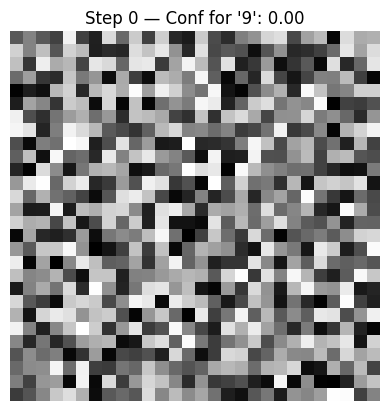

Step  10: Predicted 8 | Confidence for '9': 0.2137


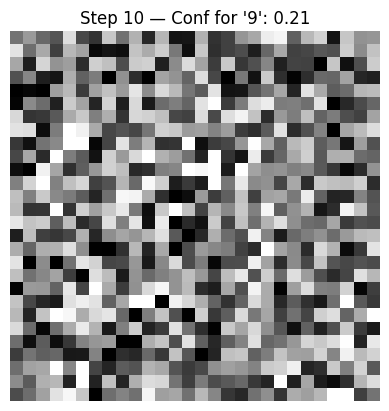

Step  20: Predicted 9 | Confidence for '9': 0.8525


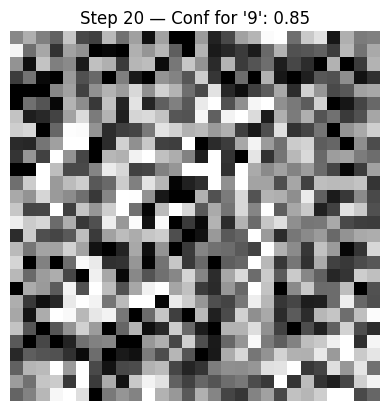

Step  30: Predicted 9 | Confidence for '9': 0.9678


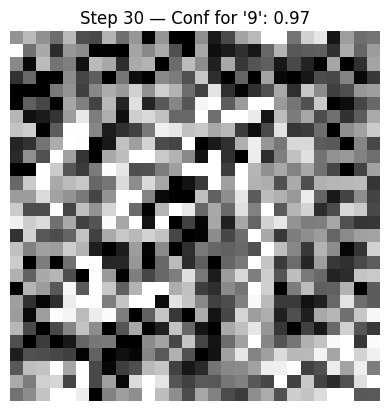

Step  40: Predicted 9 | Confidence for '9': 0.9848


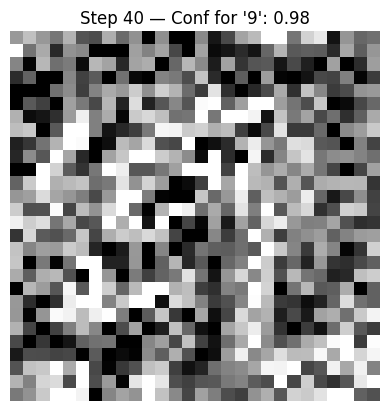

Step  50: Predicted 9 | Confidence for '9': 0.9895


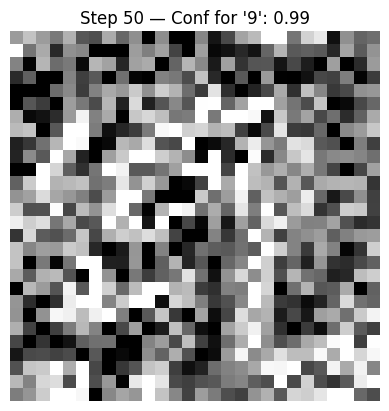

Step  60: Predicted 9 | Confidence for '9': 0.9915


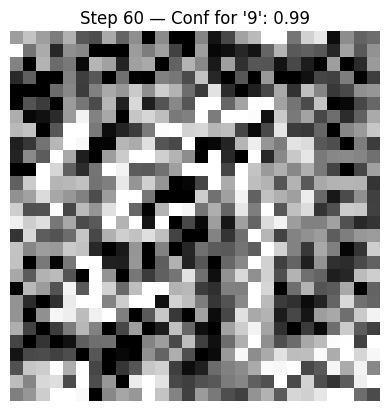

Step  70: Predicted 9 | Confidence for '9': 0.9926


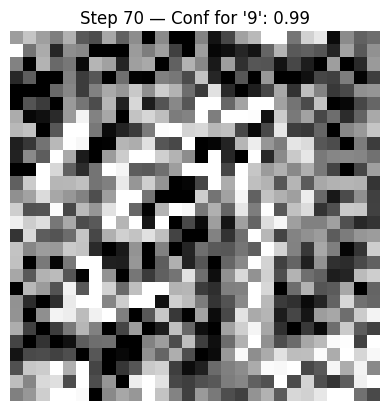

Step  80: Predicted 9 | Confidence for '9': 0.9933


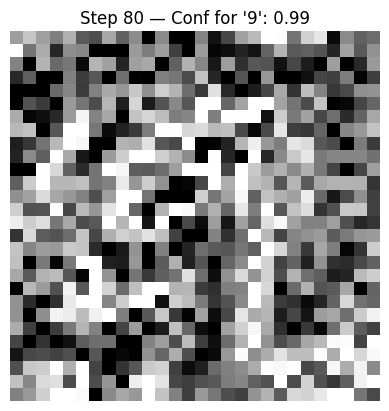

Step  90: Predicted 9 | Confidence for '9': 0.9939


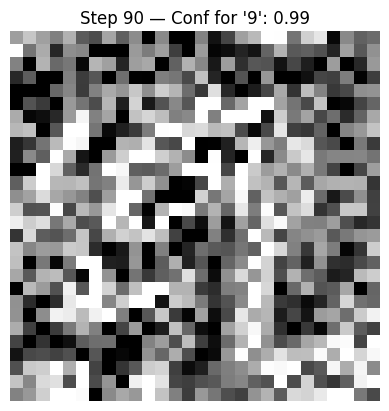

Step 100: Predicted 9 | Confidence for '9': 0.9944


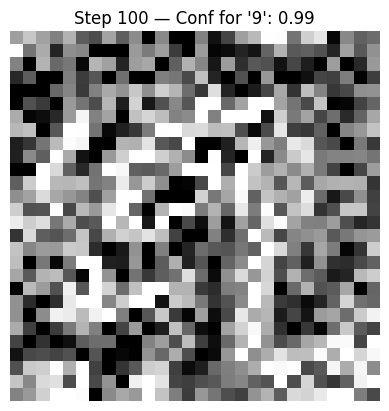

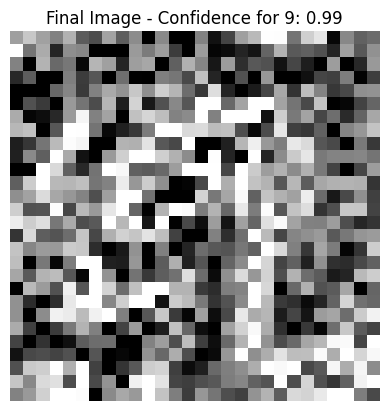


Final class probabilities:
0: 0.0001
1: 0.0000
2: 0.0002
3: 0.0016
4: 0.0013
5: 0.0018
6: 0.0000
7: 0.0001
8: 0.0004
9: 0.9944

Model confidence for '9': 0.9944


In [3]:
# Your trained model
target_class = 9
target_onehot = tf.keras.utils.to_categorical(target_class, 10).reshape(1, 10).astype(np.float32)

# Initialize random noise image (flat, since model input is (784,))
random_image = tf.Variable(np.random.rand(1, 784).astype(np.float32))

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01) # An Adam optimizer is created with a learning rate of 0.01
loss_fn = tf.keras.losses.CategoricalCrossentropy(from_logits=True) # The loss function used is categorical cross-entropy, which is appropriate for multi-class classification tasks.

# Run 101 times to optimize the image
for i in range(101):
    with tf.GradientTape() as tape:
        prediction = model(random_image) # The model makes a prediction based on the current random_image
        loss = loss_fn(target_onehot, prediction) # The loss is calculated between the predicted output and the target one-hot encoded vector.

    grads = tape.gradient(loss, random_image) # The gradients of the loss with respect to the random_image are computed
    optimizer.apply_gradients([(grads, random_image)]) # The optimizer updates the random_image based on these gradients
    random_image.assign(tf.clip_by_value(random_image, 0.0, 1.0))

    # Every 10 steps: display the image and confidence
    if i % 10 == 0:
        probs = tf.nn.softmax(prediction).numpy().squeeze() # calculate the softmax probabilites of the predictions
        pred_class = np.argmax(probs)
        confidence = probs[target_class]

        print(f"Step {i:3d}: Predicted {pred_class} | Confidence for '9': {confidence:.4f}")

        # Show the image
        plt.imshow(random_image.numpy().reshape(28, 28), cmap='gray')
        plt.title(f"Step {i} — Conf for '9': {confidence:.2f}")
        plt.axis('off')
        plt.show()

# Show final result
plt.imshow(random_image.numpy().reshape(28, 28), cmap='gray')
plt.title(f"Final Image - Confidence for 9: {confidence:.2f}")
plt.axis('off')
plt.show()

# Final probability breakdown
probs = prob_model(random_image).numpy().squeeze()
print("\nFinal class probabilities:")
for i, p in enumerate(probs):
    print(f"{i}: {p:.4f}")
print(f"\nModel confidence for '{target_class}': {probs[target_class]:.4f}")

The image doesn’t resemble any digit to the human eye, it's just structured noise.

However, the model’s confidence is 99% for class “9”.

**Comparison of Adversarial Examples vs. Random Noise Attack**

In the first part of the experiment, we used a real picture of the number 4 and made small changes to it so that the computer would think it's a 9. To us, the picture still looked like a 4, but the model was tricked and guessed 9 with high confidence. This shows how small changes can confuse the computer.

In the second part, we started with a totally random image that looked like noise. We kept adjusting it until the computer thought it was a 9. Even though the image didn’t look like any real number, the computer was completely sure it was a 9.

These two results show that while the model is good at recognizing numbers, it can still be fooled—either by slightly changing real images or even by using random noise.